# PSD Creation Tutorial

In [113]:
import qetpy as qp
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
import pytesdaq.io.hdf5 as h5io
import pickle
from astropy.stats import sigma_clip as clip

### Raw data reader function:

In [114]:
h5 = h5io.H5Reader()

def read_file(file_name): 
    traces, info = h5.read_many_events(filepath=file_name, output_format=2, 
                                       include_metadata=True,
                                       adctoamp=True)
    detector_settings = h5.get_detector_config(file_name=file_name)
    channels = info[0]['detector_chans']
    sample_rate = info[0]['sample_rate']
    
    return traces, channels, sample_rate

### Loop data, define cuts, PSD

<IPython.core.display.Javascript object>


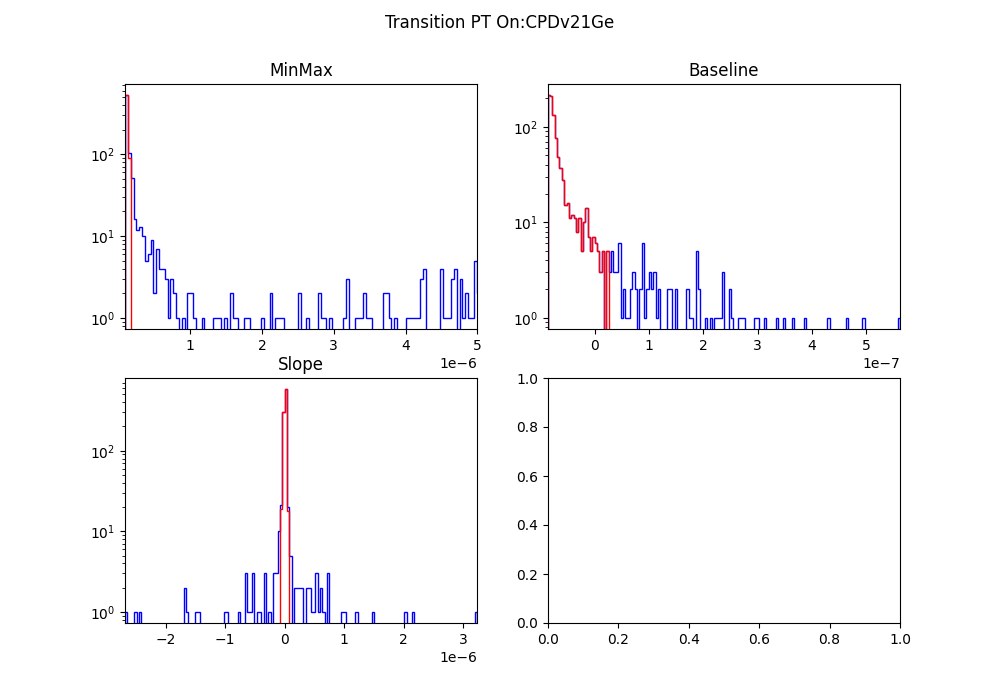

In [160]:
%matplotlib notebook

# DATA 

base_path = '/sdata2/runs/run19/raw/'
data_list = dict()
# data_list['SC PT On'] = base_path + '/random_I2_D20220721_T142026/rand_I2_D20220721_T142027_F0001.hdf5'
# data_list['SC PT Off'] = base_path + '/random_I2_D20220721_T142520/rand_I2_D20220721_T142521_F0001.hdf5'
# data_list['Normal PT On'] = base_path + '/random_I2_D20220721_T143148/rand_I2_D20220721_T143149_F0001.hdf5'
# data_list['Normal PT Off'] = base_path + '/random_I2_D20220721_T143425/rand_I2_D20220721_T143426_F0001.hdf5'
data_list['Transition PT On'] = base_path + '/random_I2_D20220721_T144630/rand_I2_D20220721_T144631_F0001.hdf5'
# data_list['Transition PT Off'] = base_path + '/random_I2_D20220721_T144852/rand_I2_D20220721_T144853_F0001.hdf5'

# data_list['No Antenna'] = base_path + '/random_I2_D20220728_T114721/rand_I2_D20220728_T114722_F0001.hdf5'
# data_list['Antenna Near OVC, ebox side'] = base_path + '/random_I2_D20220728_T115002/rand_I2_D20220728_T115003_F0001.hdf5'

# data_list[756] = base_path + 'iv_I2_D20220803_T131628/iv_I2_D20220803_T131700_F0001.hdf5'
# data_list[780] = base_path + 'iv_I2_D20220803_T131628/iv_I2_D20220803_T131834_F0001.hdf5'
# data_list[810] = base_path + 'iv_I2_D20220803_T131628/iv_I2_D20220803_T132007_F0001.hdf5'
# data_list[840] = base_path + 'iv_I2_D20220803_T131628/iv_I2_D20220803_T132141_F0001.hdf5'
# data_list[870] = base_path + 'iv_I2_D20220803_T131628/iv_I2_D20220803_T132315_F0001.hdf5'
# data_list[900] = base_path + 'iv_I2_D20220803_T131628/iv_I2_D20220803_T132449_F0001.hdf5'


# intialize PSD dictionary
noise_dict = dict()

# loop data
for data_type, file in data_list.items():
    
    #### load traces all channels [Nbevents, Nb channels, NB samples]
    traces, channels, sample_rate = read_file(file)
    
    # TEMPORARY: re-define channels as it was wrong
    channels = ['NoDevice', 'Melange1pcHangingOuter', 'Melange1pcHangingInner', 'CPDv21Ge']
    
#     channels = ['Melang1pcHangingOuter', 'CPDv21Ge']
#     traces = traces[:,[1,3],:]

    #### define cuts
    
    # 1. min_max
    min_max = traces.max(axis=2) - traces.min(axis=2)
    
    # 2. OF amplitude
    
    # 3. Baseline (=mean samples)
    baseline = traces.mean(axis=2)
    
    # 4. slope
    nb_samples = int(0.1*traces.shape[2])
    slope = traces[:,:,0:nb_samples].mean(axis=2) - traces[:,:,-nb_samples:].mean(axis=2)
    
    
    #### Apply cuts (either sequencialy or independently) (all 4 channels)
    cut_min_max = np.logical_not(clip(min_max, axis=0, sigma=2).mask)
    cut_baseline = np.logical_not(clip(baseline, axis=0, sigma_lower=5, sigma_upper=4).mask)
    cut_slope = np.logical_not(clip(slope, axis=0, sigma=4).mask)
    
    final_cut = cut_min_max & cut_baseline & cut_slope    
    
    for ichan in range(final_cut.shape[1]):
        final_cut[:,ichan] = final_cut[:,ichan] & qp.autocuts(traces[:,ichan,:],fs=1.25e6)
    
    
#     final_overall_cut = final_cut[:,0] & final_cut[:,1]
    
    
    
    
    # Calc PSD
    '''
    noise_dict[data_type] = dict()
    for ind, chan in enumerate(channels):
        noise_dict[data_type][chan] = dict()
        one_trace = traces[final_cut[:,ind],ind,:]
        f, psd = qp.calc_psd(one_trace, fs=sample_rate, folded_over=False)
        f_fold, psd_fold = qp.foldpsd(psd, sample_rate)
        noise_dict[data_type][chan]["f"] = f
        noise_dict[data_type][chan]["psd"] = psd
        noise_dict[data_type][chan]["f_fold"] = f_fold
        noise_dict[data_type][chan]["psd_fold"] = psd_fold
    '''
    # Calc correlation    
    '''
    noise_corr = qp.Noise(traces=traces[final_overall_cut], fs=sample_rate, channames=channels, name='Run 19: '+data_type)
    noise_corr.calculate_corrcoeff()
    noise_corr.plot_corrcoeff(lgcsave=False, lgcsmooth=True, nwindow=13 )
    '''
    
    #### display 
    do_display = True
    if do_display:
        
        # loop channels
        for ind, chan in enumerate(channels):
            
            if chan != 'CPDv21Ge':
                continue
            
            fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 7))
            # mean_max
#             xmax_val = float(min_max[final_cut[:,ind],ind].max())
#             xmin_val = float(min_max[final_cut[:,ind],ind].min())
            xmin = float(min_max[:,ind].min())
            xmax = float(min_max[:,ind].max())
            ax[0,0].hist(min_max[:,ind], label=f"Before cut", range=(xmin,xmax), bins=150, color='blue', histtype='step')
            ax[0,0].hist(min_max[cut_min_max[:,ind],ind], label=f"After cut", range=(xmin,xmax), bins=150, color='red', histtype='step')
#             ax[0,0].hist(min_max[final_cut[:,ind],ind], label=f"After final cut", bins=50, color="green")
            ax[0,0].set_title('MinMax')
            ax[0,0].set_yscale('log')
            ax[0,0].set_xlim(xmin, 5e-6)
            
            # baseline
            xmin = float(baseline[:,ind].min())
            xmax = float(baseline[:,ind].max())
            ax[0,1].hist(baseline[:,ind], label=f"Before cut", range=(xmin,xmax), bins=150, color='blue', histtype='step')
            ax[0,1].hist(baseline[cut_baseline[:,ind],ind], label=f"After cut", range=(xmin,xmax), bins=150, color='red', histtype='step')
#             ax[0,1].hist(baseline[final_cut[:,ind],ind], label=f"After final cut", bins=50, color="green")
            ax[0,1].set_title('Baseline')
#             xmax_val = baseline[final_cut[:,ind],ind].max()
#             xmin_val = baseline[final_cut[:,ind],ind].min()
            ax[0,1].set_yscale('log')
            ax[0,1].set_xlim(xmin, xmax)
            
            # slope
            xmin = float(slope[:,ind].min())
            xmax = float(slope[:,ind].max())
            ax[1,0].hist(slope[:,ind], label=f"Before cut", range=(xmin,xmax), bins=150, color='blue', histtype='step')
            ax[1,0].hist(slope[cut_slope[:,ind],ind], label=f"After cut", range=(xmin,xmax), bins=150, color='red', histtype='step')
#             ax[1,0].hist(slope[final_cut[:,ind],ind], label=f"After final cut", bins=50, color="green")
            ax[1,0].set_title('Slope')
            ax[1,0].set_yscale('log')
#             xmax_val = slope[final_cut[:,ind],ind].max()
#             xmin_val = slope[final_cut[:,ind],ind].min()
            ax[1,0].set_xlim(xmin, xmax)
            
            
            plt.suptitle(data_type + ':' + chan)
        
                    
           
    

## Plot a trace

### Calc PSD

In [32]:
'''noise_dict = {}
for ind, chan in enumerate(channels):
    one_trace = traces[final_cut[:,ind],ind]
    f, psd = qp.calc_psd(one_trace, fs=sample_rate, folded_over=False)
    f_fold, psd_fold = qp.foldpsd(psd, sample_rate)
    noise_dict[f"f_{chan}"] = f
    noise_dict[f"psd_{chan}"] = psd
    noise_dict[f"f_fold_{chan}"] = f_fold
    noise_dict[f"psd_fold_{chan}"] = psd_fold
# my_dict = pickle.dump(noise_dict, open('SC_PT_On.pkl', 'wb'))
# my_dict = pickle.load(open('./psd.pkl', 'rb'))'''

/usr/local/lib/python3.6/site-packages/ipykernel_launcher.py:10: ResourceWarning: unclosed file <_io.BufferedWriter name='SC_PT_On.pkl'>
  # Remove the CWD from sys.path while we load stuff.


### Plot PSD

/usr/local/lib/python3.6/site-packages/ipykernel_launcher.py:33: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
/usr/local/lib/python3.6/site-packages/ipykernel_launcher.py:33: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.


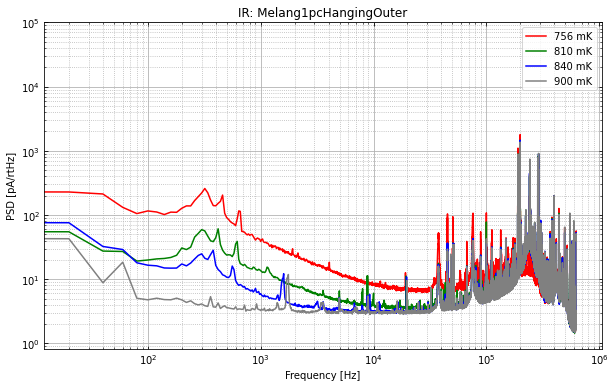

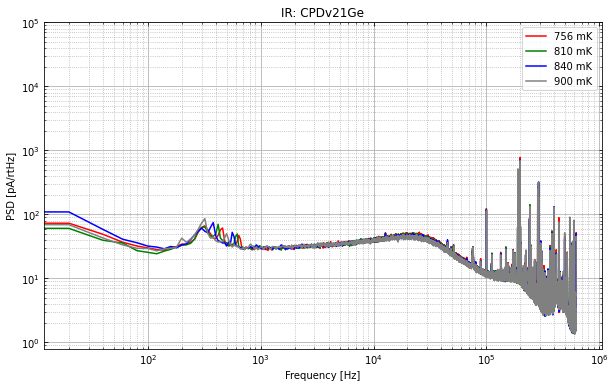

In [150]:
for chan in channels:
    fig, ax = plt.subplots(figsize=(10, 6))
    
#     ax.loglog(noise_dict['SC PT On'][chan]['f_fold'], 1e12*noise_dict['SC PT On'][chan]['psd_fold']**0.5,
#                    label=f"Data type: SC PT On", color="red")
#     ax.loglog(noise_dict['SC PT Off'][chan]['f_fold'], 1e12*noise_dict['SC PT Off'][chan]['psd_fold']**0.5,
#                    label=f"Data type: SC PT Off", color="blue")
#     ax.loglog(noise_dict['Normal PT On'][chan]['f_fold'], 1e12*noise_dict['Normal PT On'][chan]['psd_fold']**0.5,
#                    label=f"Data type: Normal PT On", color="red")
#     ax.loglog(noise_dict['Normal PT Off'][chan]['f_fold'], 1e12*noise_dict['Normal PT Off'][chan]['psd_fold']**0.5,
#                    label=f"Data type: Normal PT Off", color="blue")
#     ax.loglog(noise_dict['Transition PT On'][chan]['f_fold'], 1e12*noise_dict['Transition PT On'][chan]['psd_fold']**0.5,
#                    label=f"Data type: Transition PT On", color="red")
#     ax.loglog(noise_dict['Transition PT Off'][chan]['f_fold'], 1e12*noise_dict['Transition PT Off'][chan]['psd_fold']**0.5,
#                    label=f"Data type: Transition PT Off", color="blue")
#     ax.loglog(noise_dict['No Antenna'][chan]['f_fold'], 1e12*noise_dict['No Antenna'][chan]['psd_fold']**0.5,
#                    label=f"Data type: EMI Off", color="coral")  
#     ax.loglog(noise_dict['Antenna Near OVC, ebox side'][chan]['f_fold'], 1e12*noise_dict['Antenna Near OVC, ebox side'][chan]['psd_fold']**0.5,
#                    label=f"Data type: EMI On", color="violet")  
    ax.loglog(noise_dict[756][chan]['f_fold'], 1e12*noise_dict[756][chan]['psd_fold']**0.5, label='756 mK', color='red')
#     ax.loglog(noise_dict[780][chan]['f_fold'], 1e12*noise_dict[780][chan]['psd_fold']**0.5, label='780 mK', color='orange')
    ax.loglog(noise_dict[810][chan]['f_fold'], 1e12*noise_dict[810][chan]['psd_fold']**0.5, label='810 mK', color='green')
    ax.loglog(noise_dict[840][chan]['f_fold'], 1e12*noise_dict[840][chan]['psd_fold']**0.5, label='840 mK', color='blue')
#     ax.loglog(noise_dict[870][chan]['f_fold'], 1e12*noise_dict[870][chan]['psd_fold']**0.5, label='870 mK', color='violet')
    ax.loglog(noise_dict[900][chan]['f_fold'], 1e12*noise_dict[900][chan]['psd_fold']**0.5, label='900 mK', color='gray')

       
    ax.legend()
    ax.tick_params(which="both", direction="in", right=True, top=True)
    ax.grid(which="minor", linestyle="dotted")
    ax.grid(which="major")
    ax.set_title("IR: "+chan)
    ax.set_ylim(0, 1e5)
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("PSD [pA/rtHz]")

#ax.set_ylim(1e-12,1e-8);

Save the dictionary

In [16]:
an_array = np.asarray([1.2,3,1.5,2.6,4.1])
new_array = np.array([])
for i in range (len(an_array)):
    if an_array[i,] < 4:
        new_array = np.append(new_array, an_array[i,])

# print(len(an_array))
print(new_array)

5
[1.2 3.  1.5 2.6]


In [18]:
print(an_array < 4)

[ True  True  True  True False]


In [52]:
pprint(noise_dict)

{'Normal PT On': {'CPDv21Ge': {'f': array([  0.,  10.,  20., ..., -30., -20., -10.]),
                               'f_fold': array([0.0000e+00, 1.0000e+01, 2.0000e+01, ..., 6.2498e+05, 6.2499e+05,
       6.2500e+05]),
                               'psd': array([1.27066173e-14, 7.49019323e-21, 6.98665047e-22, ...,
       2.50647195e-22, 6.98665047e-22, 7.49019323e-21]),
                               'psd_fold': array([1.27066173e-14, 1.49803865e-20, 1.39733009e-21, ...,
       3.15501460e-21, 3.13343488e-21, 1.89582624e-21])},
                  'Melange1pcHangingInner': {'f': array([  0.,  10.,  20., ..., -30., -20., -10.]),
                                             'f_fold': array([0.0000e+00, 1.0000e+01, 2.0000e+01, ..., 6.2498e+05, 6.2499e+05,
       6.2500e+05]),
                                             'psd': array([1.29272672e-15, 7.57065200e-21, 4.47469306e-22, ...,
       2.06371833e-23, 4.47469306e-22, 7.57065200e-21]),
                                             'p